In [5]:
import os
os.makedirs("/workspaces/retail-sales-analytics/exports", exist_ok=True)

# Full dataset
df.to_csv("/workspaces/retail-sales-analytics/exports/orders_full.csv", index=False)

# Category summary for Tableau
cat_summary = df.groupby(["category", "subcategory"]).agg(
    revenue=("sales", "sum"),
    profit=("profit", "sum"),
    avg_discount=("discount", "mean"),
    order_count=("quantity", "count")
).reset_index()
cat_summary["margin_pct"] = (cat_summary["profit"] / cat_summary["revenue"] * 100).round(2)
cat_summary.to_csv("/workspaces/retail-sales-analytics/exports/category_summary.csv", index=False)

# Discount analysis for Tableau
disc_summary = df.groupby("discount").agg(
    orders=("quantity", "count"),
    avg_profit=("profit", "mean"),
    total_profit=("profit", "sum")
).reset_index().round(2)
disc_summary.to_csv("/workspaces/retail-sales-analytics/exports/discount_analysis.csv", index=False)

print("Exports complete")
print(f"orders_full: {len(df)} rows")
print(f"category_summary: {len(cat_summary)} rows")
print(f"discount_analysis: {len(disc_summary)} rows")


Exports complete
orders_full: 9994 rows
category_summary: 17 rows
discount_analysis: 12 rows


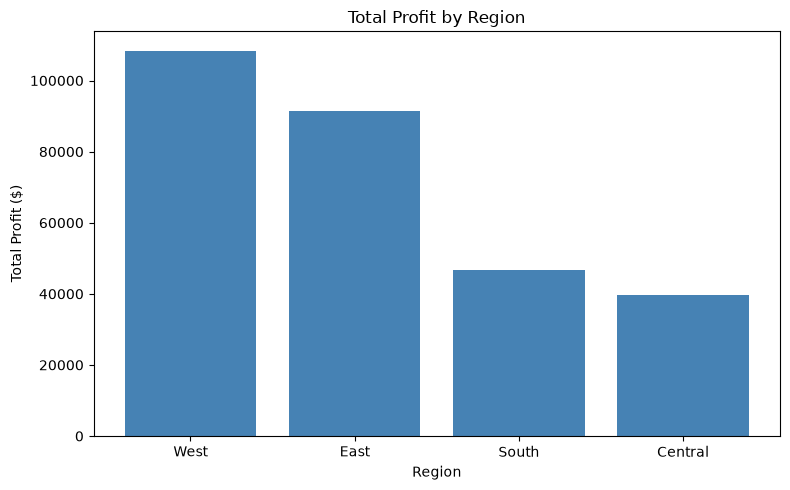

In [4]:
region_profit = df.groupby("region")["profit"].sum().reset_index()
region_profit = region_profit.sort_values("profit", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region_profit["region"], region_profit["profit"], color="steelblue")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()


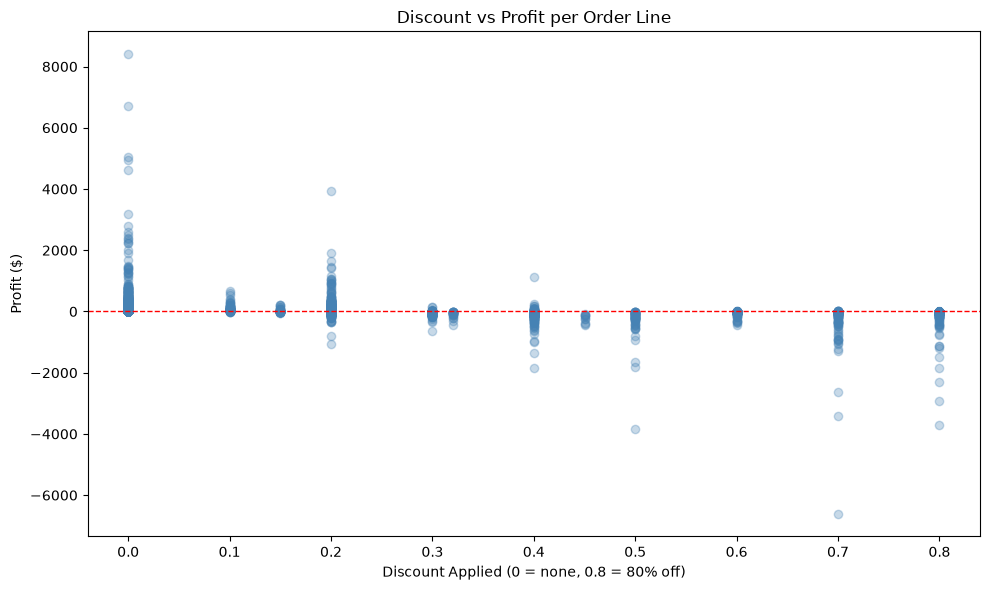

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(df["discount"], df["profit"], alpha=0.3, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.title("Discount vs Profit per Order Line")
plt.xlabel("Discount Applied (0 = none, 0.8 = 80% off)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Total Profit ($)')

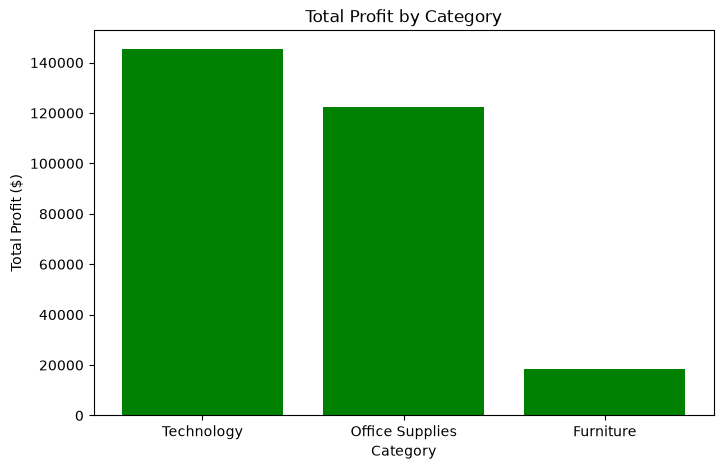

In [2]:
cat_profit = df.groupby("category")["profit"].sum().reset_index()
cat_profit = cat_profit.sort_values("profit", ascending=False)

plt.figure(figsize=(8,5))
colors = ["green" if x > 0 else "red" for x in cat_profit["profit"]]
plt.bar(cat_profit["category"], cat_profit["profit"], color=colors)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")


In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

conn = psycopg2.connect(
    host="localhost", port=5432,
    database="retail_sales",
    user="postgres", password="postgres123"
)

df = pd.read_sql("SELECT * FROM orders", conn)
print(df.shape)           # should be (9994, 13)
print(df.columns.tolist())  # verify all 13 column names
df.head()


(9994, 13)
['shipmode', 'segment', 'country', 'city', 'state', 'postalcode', 'region', 'category', 'subcategory', 'sales', 'quantity', 'discount', 'profit']


/tmp/ipykernel_50144/3688033152.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM orders", conn)


,shipmode,segment,country,city,state,postalcode,region,category,subcategory,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52
